In [7]:
from google.colab import files
uploaded = files.upload() # Please upload 'housing.csv.zip' when prompted

import zipfile

with zipfile.ZipFile('/content/housing.csv.zip', 'r') as z:
    z.extractall('.')
    print("Unzipped! Files:", z.namelist())

Saving housing.csv.zip to housing.csv.zip
Unzipped! Files: ['housing.csv']


Load and Explore


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('housing.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic stats:")
print(df.describe())

Shape: (20640, 10)

First 5 rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Missing values:
longitude               

Plotting

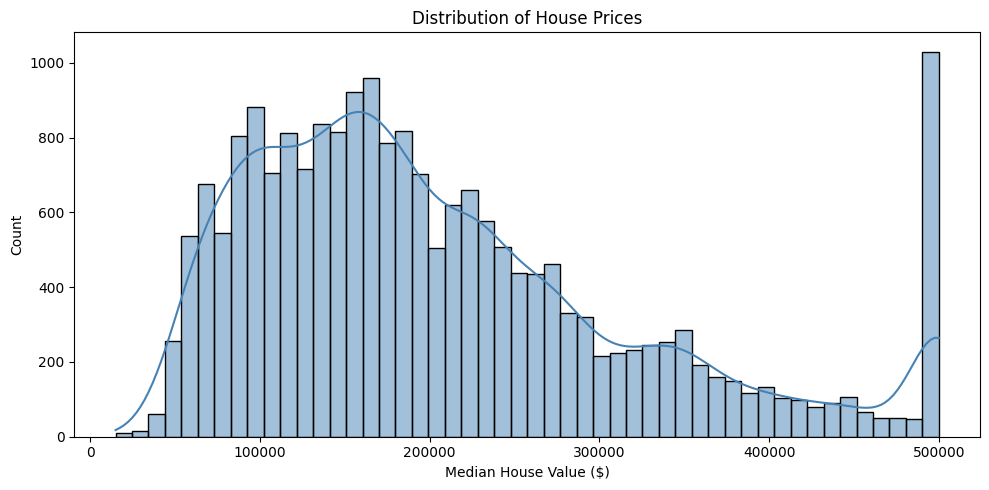

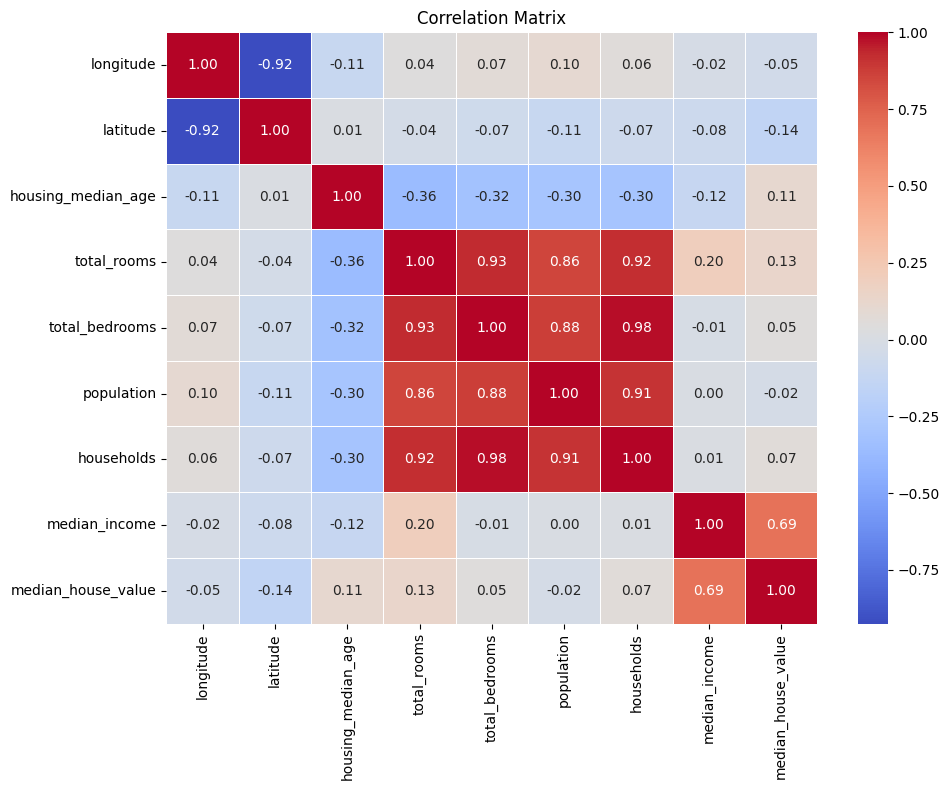

In [9]:
# Price distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['median_house_value'], kde=True, color='steelblue', bins=50)
plt.title('Distribution of House Prices')
plt.xlabel('Median House Value ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True,
            fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Data Cleaning and Feature Engineering

In [11]:
# ── STEP 2: DATA CLEANING ────────────────────────────────────

# Fix the 207 missing values in total_bedrooms
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

# Verify no more missing values
print("Missing values after fix:")
print(df.isnull().sum())
print("\nAll clean! ✅")

Missing values after fix:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

All clean! ✅


/tmp/ipykernel_253/3431871522.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)


In [12]:
# ── STEP 3: FEATURE ENGINEERING ─────────────────────────────
# The original columns are per-block totals, not very meaningful
# We create per-household ratios which are far more useful

df['rooms_per_household']      = df['total_rooms']    / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']     / df['households']

# Encode the ocean_proximity text column into numbers
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

print("New shape after feature engineering:", df.shape)
print("\nNew columns added:")
print(df.columns.tolist())

New shape after feature engineering: (20640, 16)

New columns added:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


Prepare X and Y

In [13]:
# ── STEP 4: DEFINE FEATURES AND TARGET ───────────────────────
X = df.drop('median_house_value', axis=1)   # everything except price
y = df['median_house_value']                # the price we want to predict

print("Features shape:", X.shape)
print("Target shape  :", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (20640, 15)
Target shape  : (20640,)

Feature columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


Model Building

Split data into Train and Test

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size :", X_train.shape)
print("Testing size  :", X_test.shape)

Training size : (16512, 15)
Testing size  : (4128, 15)


Train Linear Regression(Baseline)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# Build pipeline: scale first, then model
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
lr_preds = lr_pipeline.predict(X_test)

# Evaluate
lr_r2   = r2_score(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print("── Linear Regression ──────────────────")
print(f"R² Score : {lr_r2:.3f}")
print(f"RMSE     : ${lr_rmse:,.0f}")

── Linear Regression ──────────────────
R² Score : 0.597
RMSE     : $72,669


Train XG Boost

In [16]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=0
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
xgb_preds = xgb_model.predict(X_test)

# Evaluate
xgb_r2   = r2_score(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

print("── XGBoost ─────────────────────────────")
print(f"R² Score : {xgb_r2:.3f}")
print(f"RMSE     : ${xgb_rmse:,.0f}")

── XGBoost ─────────────────────────────
R² Score : 0.832
RMSE     : $46,915


Compare both models

In [17]:
print("╔══════════════════════════════════════╗")
print("║        MODEL COMPARISON               ║")
print("╠══════════════════════════════════════╣")
print(f"║ Linear Regression  R²  : {lr_r2:.3f}        ║")
print(f"║ XGBoost            R²  : {xgb_r2:.3f}        ║")
print("╠══════════════════════════════════════╣")
print(f"║ Linear Regression  RMSE: ${lr_rmse:,.0f}   ║")
print(f"║ XGBoost            RMSE: ${xgb_rmse:,.0f}   ║")
print("╚══════════════════════════════════════╝")

improvement = ((lr_r2 - xgb_r2) / lr_r2) * -100
print(f"\nXGBoost is {improvement:.1f}% better than Linear Regression!")

╔══════════════════════════════════════╗
║        MODEL COMPARISON               ║
╠══════════════════════════════════════╣
║ Linear Regression  R²  : 0.597        ║
║ XGBoost            R²  : 0.832        ║
╠══════════════════════════════════════╣
║ Linear Regression  RMSE: $72,669   ║
║ XGBoost            RMSE: $46,915   ║
╚══════════════════════════════════════╝

XGBoost is 39.4% better than Linear Regression!


SHAP (SHapley Additive Explanations)

In [18]:
# SHAP is pre-installed in Colab but let's make sure
!pip install shap -q

import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [19]:
# Create explainer using our trained XGBoost model
explainer = shap.Explainer(xgb_model)

# Calculate SHAP values for the test set
# This takes 30-60 seconds — normal!
shap_values = explainer(X_test)

print("SHAP values shape:", shap_values.shape)
print("Done! ✅")

SHAP values shape: (4128, 15)
Done! ✅


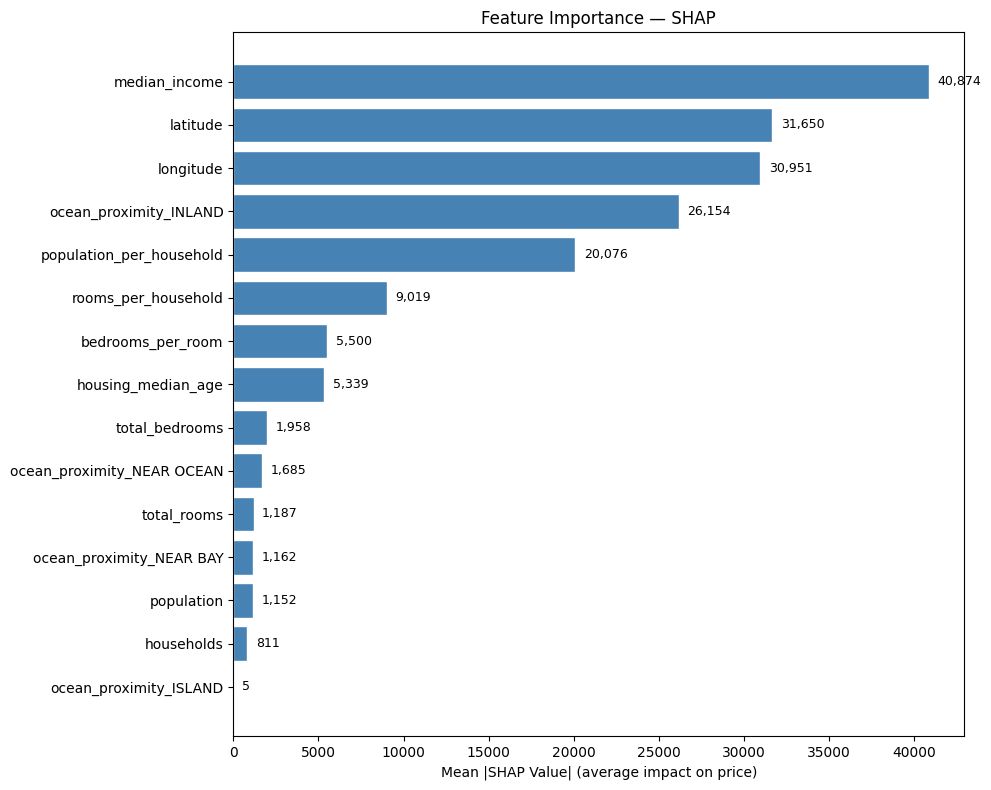

In [20]:
# Fixed Feature Importance Bar Chart
shap_vals_array = shap_values.values
feature_names = X_test.columns.tolist()

# Calculate mean absolute SHAP value for each feature
mean_shap = np.abs(shap_vals_array).mean(axis=0)

# Sort by importance
sorted_idx = np.argsort(mean_shap)
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_values = mean_shap[sorted_idx]

# Plot
plt.figure(figsize=(10, 8))
bars = plt.barh(sorted_features, sorted_values, color='steelblue', edgecolor='white')

# Add value labels on each bar
for bar, val in zip(bars, sorted_values):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=9)

plt.xlabel('Mean |SHAP Value| (average impact on price)')
plt.title('Feature Importance — SHAP')
plt.tight_layout()
plt.show()

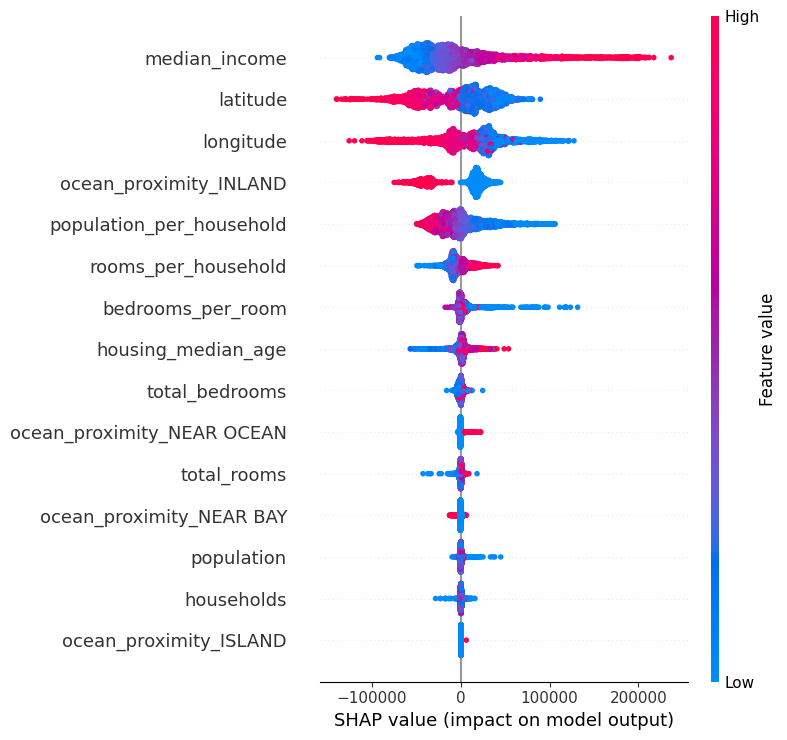

<Figure size 640x480 with 0 Axes>

In [21]:
# This shows HOW each feature affects price (up or down)
shap.summary_plot(shap_values, X_test)
plt.tight_layout()
plt.show()

Actual price    : $47,700
Predicted price : $56,645


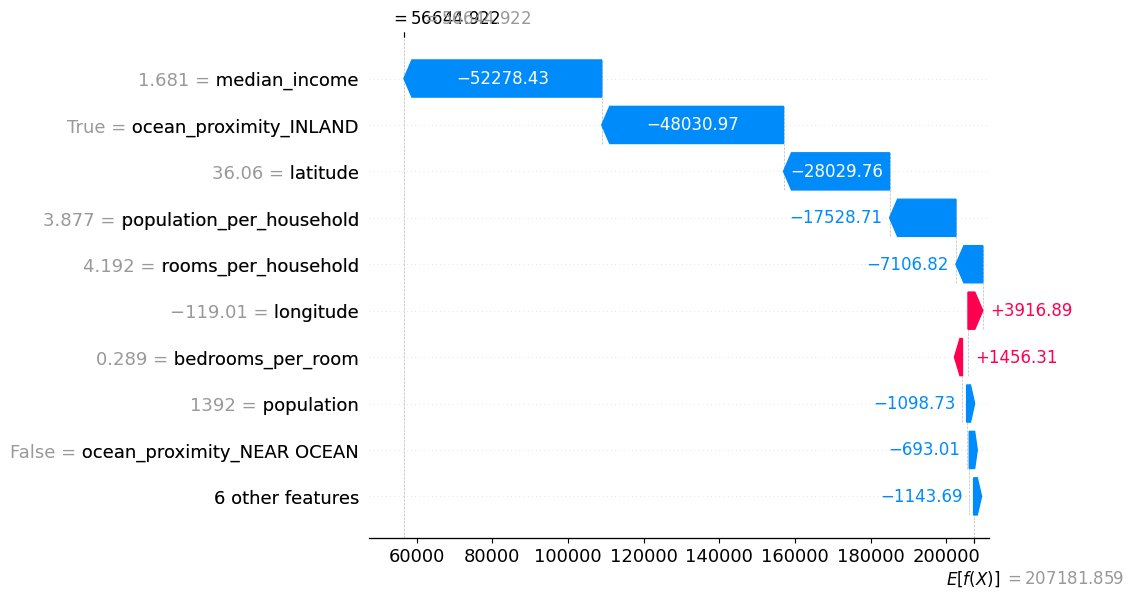

In [22]:
# Pick the first house in test set and explain its prediction
print(f"Actual price    : ${y_test.iloc[0]:,.0f}")
print(f"Predicted price : ${xgb_model.predict(X_test.iloc[[0]])[0]:,.0f}")

# Waterfall chart
shap.plots.waterfall(shap_values[0])

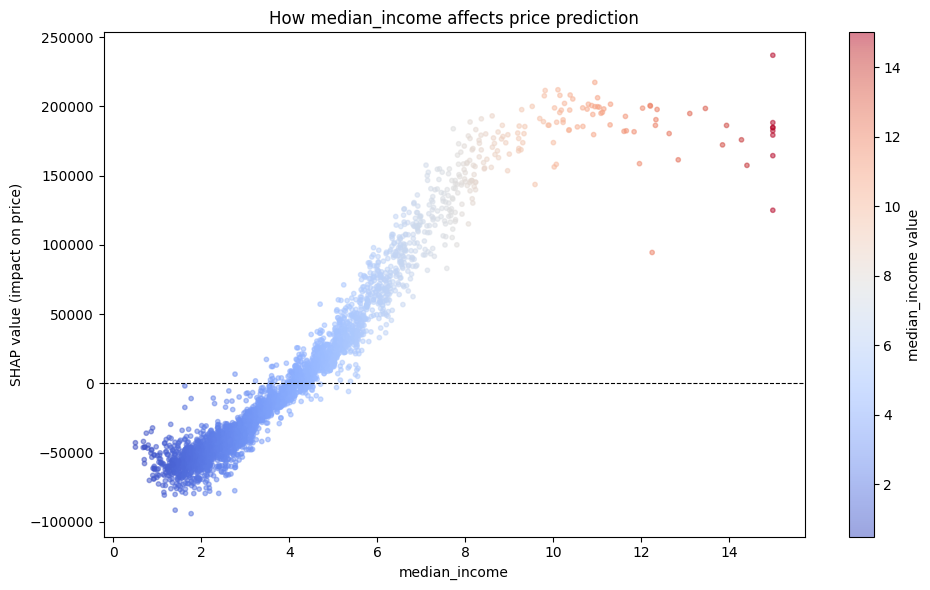

In [23]:
# Fixed dependence plot
shap_vals_array = shap_values.values
feature_names = X_test.columns.tolist()
median_income_idx = feature_names.index('median_income')

plt.figure(figsize=(10, 6))
plt.scatter(
    X_test['median_income'],
    shap_vals_array[:, median_income_idx],
    c=X_test['median_income'],
    cmap='coolwarm',
    alpha=0.5,
    s=10
)
plt.colorbar(label='median_income value')
plt.xlabel('median_income')
plt.ylabel('SHAP value (impact on price)')
plt.title('How median_income affects price prediction')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

Testing

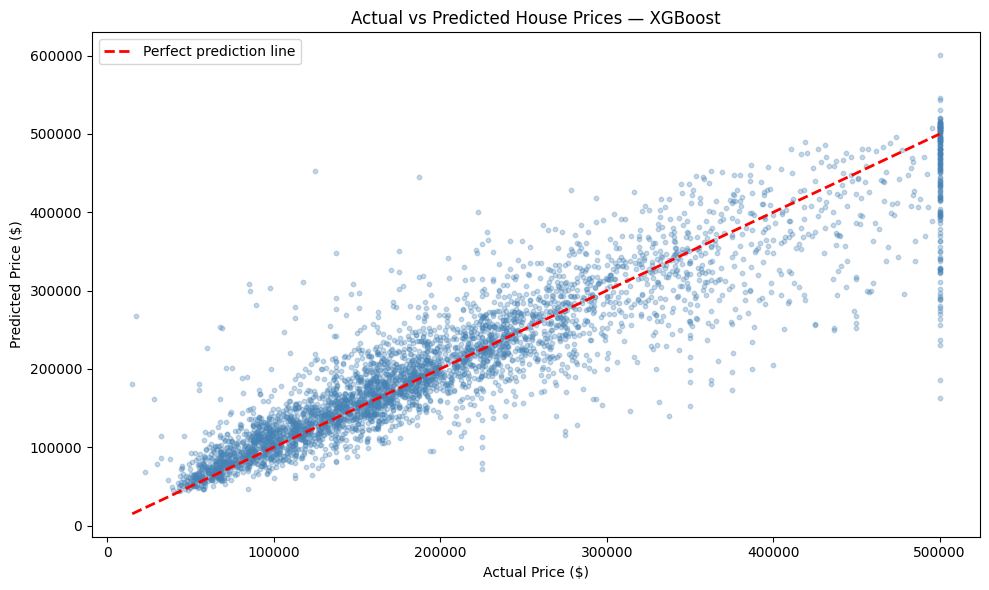

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Compare actual vs predicted on test set
plt.figure(figsize=(10, 6))
plt.scatter(y_test, xgb_preds, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices — XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

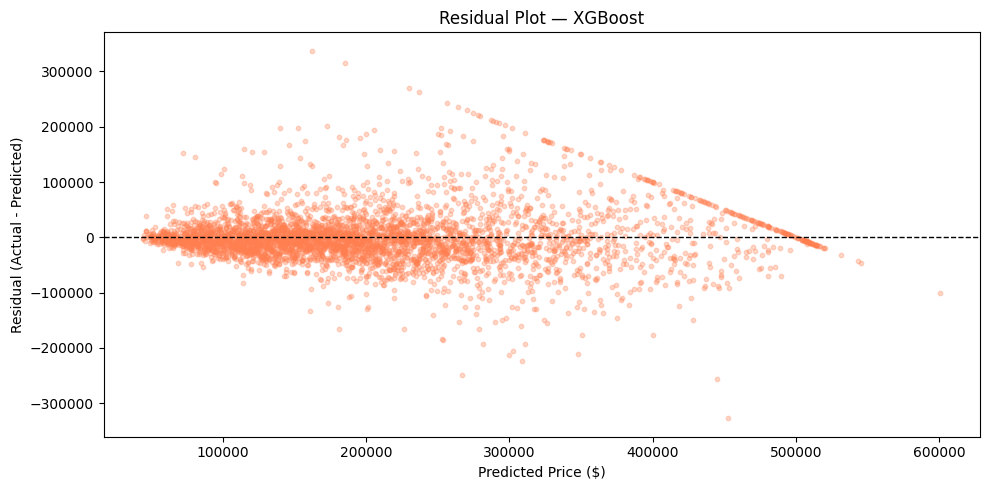

Mean residual : $-1,170  (should be close to 0)
Std residual  : $46,906


In [25]:
# Residuals = difference between actual and predicted
residuals = y_test - xgb_preds

plt.figure(figsize=(10, 5))
plt.scatter(xgb_preds, residuals, alpha=0.3, s=10, color='coral')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot — XGBoost')
plt.tight_layout()
plt.show()

print(f"Mean residual : ${residuals.mean():,.0f}  (should be close to 0)")
print(f"Std residual  : ${residuals.std():,.0f}")

In [26]:
# Create a brand new house the model has NEVER seen
import pandas as pd

new_house = pd.DataFrame({
    'longitude'                : [-122.23],
    'latitude'                 : [37.88],
    'housing_median_age'       : [25],
    'total_rooms'              : [3500],
    'total_bedrooms'           : [700],
    'population'               : [1200],
    'households'               : [400],
    'median_income'            : [6.5],
    'rooms_per_household'      : [3500 / 400],
    'bedrooms_per_room'        : [700 / 3500],
    'population_per_household' : [1200 / 400],
    'ocean_proximity_INLAND'   : [0],
    'ocean_proximity_ISLAND'   : [0],
    'ocean_proximity_NEAR BAY' : [1],
    'ocean_proximity_NEAR OCEAN': [0],
})

# Make sure columns match training data
new_house = new_house[X_train.columns]

# Predict
predicted_price = xgb_model.predict(new_house)[0]
print("═══════════════════════════════════════")
print("        NEW HOUSE DETAILS               ")
print("═══════════════════════════════════════")
print(f"  Location     : Near Bay Area")
print(f"  House age    : 25 years")
print(f"  Median income: $65,000")
print(f"  Rooms/house  : {3500/400:.1f}")
print("═══════════════════════════════════════")
print(f"  Predicted Price : ${predicted_price:,.0f}")
print("═══════════════════════════════════════")

═══════════════════════════════════════
        NEW HOUSE DETAILS               
═══════════════════════════════════════
  Location     : Near Bay Area
  House age    : 25 years
  Median income: $65,000
  Rooms/house  : 8.8
═══════════════════════════════════════
  Predicted Price : $340,679
═══════════════════════════════════════
